# 機械学習帳第４回の解答

> 今回だけは確認問題の中に記述解答が必要なものがあったため，「しぶしぶ」Jupyterを使います

## 第１問

確率的勾配降下法の更新式は式4.28より以下のように表せる

$$
\begin{equation}
    \boldsymbol{w}^{(t+1)} = \boldsymbol{w}^{(t)} - \eta_t \nabla \hat{l}_{x,y}(\boldsymbol{w}^{(t)})
    \tag{1}
\end{equation}
$$

リッジ回帰において目的関数$\hat{L}_D(\boldsymbol{w})$は，ハイパーパラメータ$\alpha$を用いて式3.3より次のように表される

$$
\begin{equation}
    \begin{split}
        \hat{L}_D(\boldsymbol{w}) &= || \boldsymbol{y} - \boldsymbol{Xw} ||^2 + \alpha|| \boldsymbol{w} ||^2 \\
        &= \sum_{i=1}^{N}(y_i - \boldsymbol{x}_i^{\top}\boldsymbol{w})^2 + \alpha|| \boldsymbol{w} ||^2 \\
        &= \sum_{i=1}^{N}\left((y_i - \boldsymbol{x}_i^{\top}\boldsymbol{w})^2 + \frac{\alpha}{N}|| \boldsymbol{w} ||^2 \right)
    \end{split}
    \tag{2}
\end{equation}
$$

ここで，それぞれの損失$\hat{l}_{x_i,y_i}(\boldsymbol{w})$は，$\hat{L}_D(\boldsymbol{w}) = \sum_{i=1}^{N}\hat{l}_{x_i,y_i}(\boldsymbol{w})$であることから，

$$
\begin{equation}
    \hat{l}_{x_i,y_i}(\boldsymbol{w}) = (y_i - \boldsymbol{x}_i^{\top}\boldsymbol{w})^2 + \frac{\alpha}{N}|| \boldsymbol{w} ||^2
    \tag{3}
\end{equation}
$$

よって，これを$\boldsymbol{w}$について偏微分すると，

$$
\begin{equation}
    \nabla \hat{l}_{x_i,y_i}(\boldsymbol{w}) = -2(y_i - \boldsymbol{x_i}^{\top}\boldsymbol{w})\boldsymbol{x_i} + \frac{2\alpha}{N}\boldsymbol{w} = 2(\hat{y}_i - y_i)\boldsymbol{x_i} + \frac{2\alpha}{N}\boldsymbol{w}
    \tag{4}
\end{equation}
$$

以上より，リッジ回帰におけるパラメータの更新式は式(1)に$\nabla \hat{l}_{x_i,y_i}(\boldsymbol{w})$を代入することで，次のように定式化される．

$$
\begin{equation}
    \boldsymbol{w}^{(t+1)} = \left(1 - \frac{2\alpha\eta_t}{N} \right)\boldsymbol{w}^{(t)} - 2\eta_t(\hat{y}_i^{(t)} - y_i)\boldsymbol{x_i}
    \tag{5}
\end{equation}
$$


## 第２問

パラメータ$\boldsymbol{w}^{(t)}$に$-\frac{2\alpha\eta_t}{N}$がつくことにより，更新時の$\boldsymbol{w}^{(t)}$の値が一般的な重回帰よりも小さくなる．

つまり，パラメータ更新の値が減衰することによって，$L_2$ノルムの肥大化を抑制している．

## 第３問

与えられたデータが`test1_3.py`と同じものであるため，確認問題にて行ったパラメータチューニングに基づき，次数は9，$\alpha = 10^{-6}$を用いて，以下のとおり多項式近似の曲線を算出した．

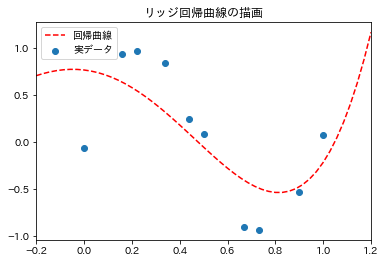

In [20]:
import japanize_matplotlib
import matplotlib.pyplot as plt
import numpy as np


def __makeX(x:np.ndarray, dim=1):
    """
    もともとのx座標に定数項部分と累乗部分を付け足して回帰計算ができる行列形式に整形したXを出力
    """
    # 定数項を定義
    X = np.insert(x.reshape((-1, 1)), 0, 1, axis=1)
    # 累乗部分を付け足していく
    for i in range(dim-1):
        X = np.insert(X, i+2, x**(i+2), axis=1)

    return X


def calcW(x:np.ndarray, y:np.ndarray, alpha=1e-6, dim=9, eta0=0.03, epoch=40000, eps=1e-4):
    """
    与えられたデータに基づき，確率的勾配法を用いてパラメータ`w`を算出する

    Parameters
    ---
    - `alpha`: リッジ回帰のパラメータ
    - `dim`: 重回帰における近似式の次数
    - `eta`: 初期学習率
    - `epoch`: パラメータ更新回数
    - `eps`: 勾配消失の閾値（この値よりも勾配が小さくなったらパラメータ`w`を確定させる）
    """
    X = __makeX(x, dim)
    w = np.zeros(dim+1)

    for t in range(int(epoch)):
        # 学習率を徐々に小さくする
        eta = eta0 / np.sqrt(1 + t)

        # 確率的に選択して勾配を計算
        i = np.random.randint(0, X.shape[0])
        grad = 2 * (X[i].T@w - y[i]) * X[i]

        # 勾配が十分に小さくなっていればパラメータ更新を終了
        if np.sum(np.abs(grad)) < eps: break

        # パラメータを更新し，次の更新へ
        w = (1 - 2*alpha*eta/X.shape[0])*w - eta*grad

    return w


def plot(x:np.ndarray, y:np.ndarray, w:np.ndarray, dim=9, sideMargin=0.2):
    """
    推定したパラメータを用いて，回帰曲線の描画を行う
    """
    x_line = np.linspace(x.min()-sideMargin, x.max()+sideMargin)
    plotX = __makeX(x_line, dim)
    plt.plot(x_line, plotX @ w, '--r', label='回帰曲線')

    # 実データの散布図
    plt.scatter(x, y, label='実データ')

    # 描画範囲を指定することで，直線の左右が途切れないように描画する
    plt.xlim(x.min()-sideMargin, x.max()+sideMargin)

    plt.title('リッジ回帰曲線の描画')
    plt.legend()
    plt.show()


if __name__ == "__main__":
    x = np.array([ 0.  ,  0.16,  0.22,  0.34,  0.44,  0.5 ,  0.67,  0.73,  0.9 ,  1.  ])
    y = np.array([-0.06,  0.94,  0.97,  0.85,  0.25,  0.09, -0.9 , -0.93, -0.53,  0.08])

    # 各引数を変更した際の描画の変化を確認せよ
    dim = 4
    w = calcW(x, y, epoch=1e7, eps=1e-10, dim=dim)

    # 図の描画
    plot(x, y, w, dim=dim)